In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import STL

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * # mae imported

In [102]:
# import the ADF test
from statsmodels.tsa.stattools import adfuller

# create a function that returns the necessary metrics to test stationarity
def test_stationarity(timeseries):
    dftest_initial = adfuller(timeseries)
    dfoutput_initial = pd.Series(dftest_initial[0:4], 
          index=['Statistical Test', 
                 'p-value', 
                 '#Lags used', 
                 'Number of observations'
                 ])
    for key, value in dftest_initial[4].items():
        dfoutput_initial['Critical value ' + key] = value
    print(dfoutput_initial)
    print('\n')

In [103]:
data = pd.read_csv("../../Downloads/iex_dam_feb_mar_2026.csv")

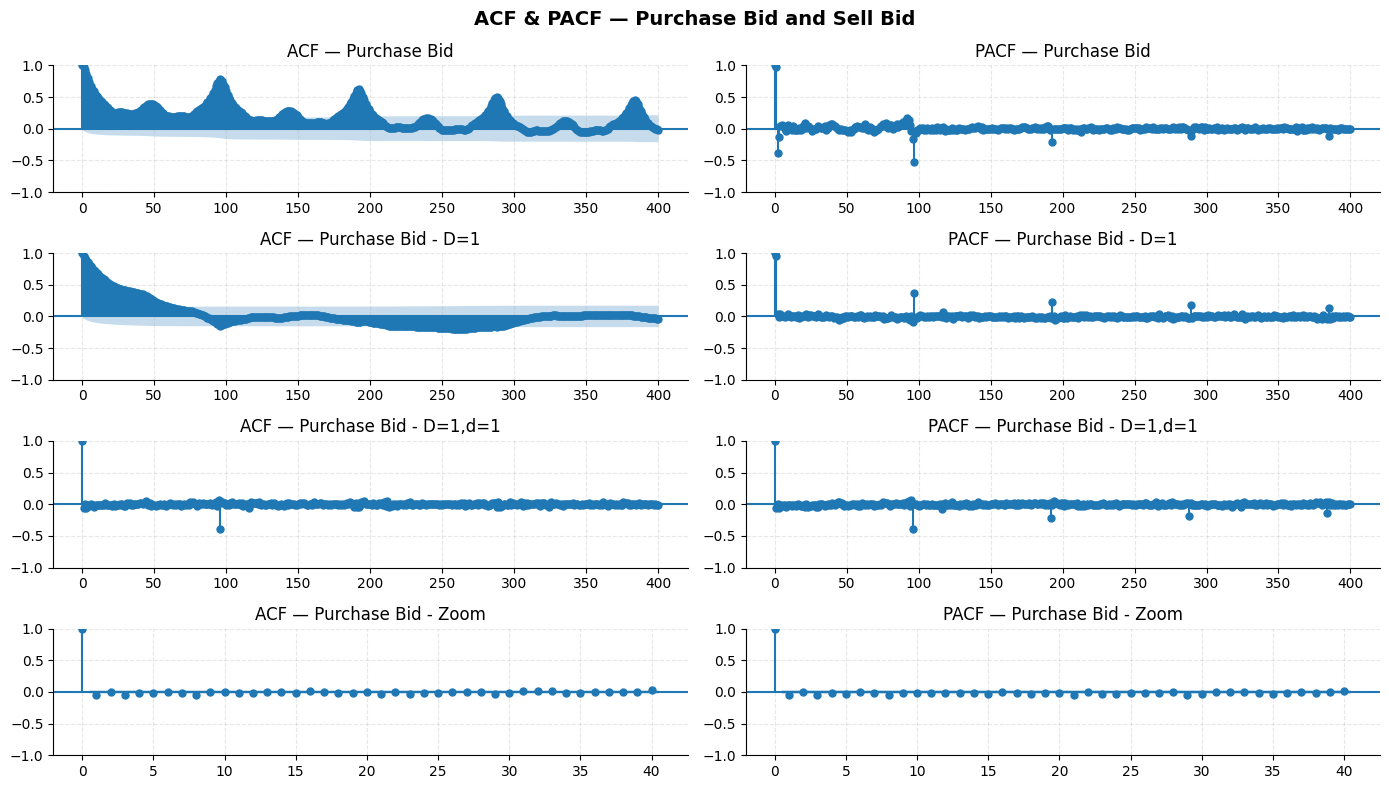

In [105]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(14, 8))
fig.suptitle("ACF & PACF — Purchase Bid and Sell Bid", fontsize=14, fontweight="bold")

plot_acf(data["purchase_bid"].dropna(),  lags=400, ax=axes[0, 0], title="ACF — Purchase Bid")
plot_pacf(data["purchase_bid"].dropna(), lags=400, ax=axes[0, 1], title="PACF — Purchase Bid")
plot_acf(data["purchase_bid"].diff(96).dropna(),  lags=400, ax=axes[1, 0], title="ACF — Purchase Bid - D=1")
plot_pacf(data["purchase_bid"].diff(96).dropna(), lags=400, ax=axes[1, 1], title="PACF — Purchase Bid - D=1")
plot_acf(data["purchase_bid"].diff(96).diff().dropna(),  lags=400, ax=axes[2, 0], title="ACF — Purchase Bid - D=1,d=1")
plot_pacf(data["purchase_bid"].diff(96).diff().dropna(), lags=400, ax=axes[2, 1], title="PACF — Purchase Bid - D=1,d=1")
plot_acf(data["purchase_bid"].diff(96).diff().dropna(),  lags=40, ax=axes[3, 0], title="ACF — Purchase Bid - Zoom")
plot_pacf(data["purchase_bid"].diff(96).diff().dropna(), lags=40, ax=axes[3, 1], title="PACF — Purchase Bid - Zoom")

# plot_acf(data["sell_bid"].diff(96).diff().dropna(),      lags=400, ax=axes[1, 0], title="ACF — Sell Bid")
# plot_pacf(data["sell_bid"].diff(96).diff().dropna(),     lags=400, ax=axes[1, 1], title="PACF — Sell Bid")

# plot_acf(data["purchase_bid"].dropna(),  lags=200, ax=axes[0, 0], title="ACF — Purchase Bid")
# plot_pacf(data["purchase_bid"].dropna(), lags=200, ax=axes[0, 1], title="PACF — Purchase Bid")
# plot_acf(data["sell_bid"].dropna(),      lags=200, ax=axes[1, 0], title="ACF — Sell Bid")
# plot_pacf(data["sell_bid"].dropna(),     lags=200, ax=axes[1, 1], title="PACF — Sell Bid")

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

From the plots in data exploration notebook, it's evident that we should focus on modeling SARIMA time series.
- Now, SARIMA requires 7 parameters (p,d,q)(P,D,Q)m
- Here m is clearly 96 (1 day) since cyclicity is evident in a day.
- We will first start with D and d to reach stationarity. 
- After differencing with D=1, I am seeing hints of stationarity achieved. 
- Will then difference again with d=1, I am seeing ACF decaying exponentially now.
- Then I am seeing spikes at lag 96 in ACF and multiples of 96 in PACF. This gives me my Q=1 and P=1,2,3...
- Then, to get small p and q, we will zoom and see there are no significant spikes, so we will keep them 0 or 1 for now.

Although to have a baseline to compare against, I will first implement baseline models as well.

Now, in order to use a faster library of StatsForecast, I need to transform the columns as below

In [106]:
data = data.rename(columns={
    'period_start': 'ds',  # Your timestamp
    'purchase_bid': 'y'             # The target value you want to plot (Market Clearing Price)
})
filtered_data = data[[ "ds", "y" ]]
filtered_data['unique_id'] = 'series_1'
filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_95471/3798344235.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['unique_id'] = 'series_1'
/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_95471/3798344235.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])


In [107]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA, ARIMA

### Predict a week in future

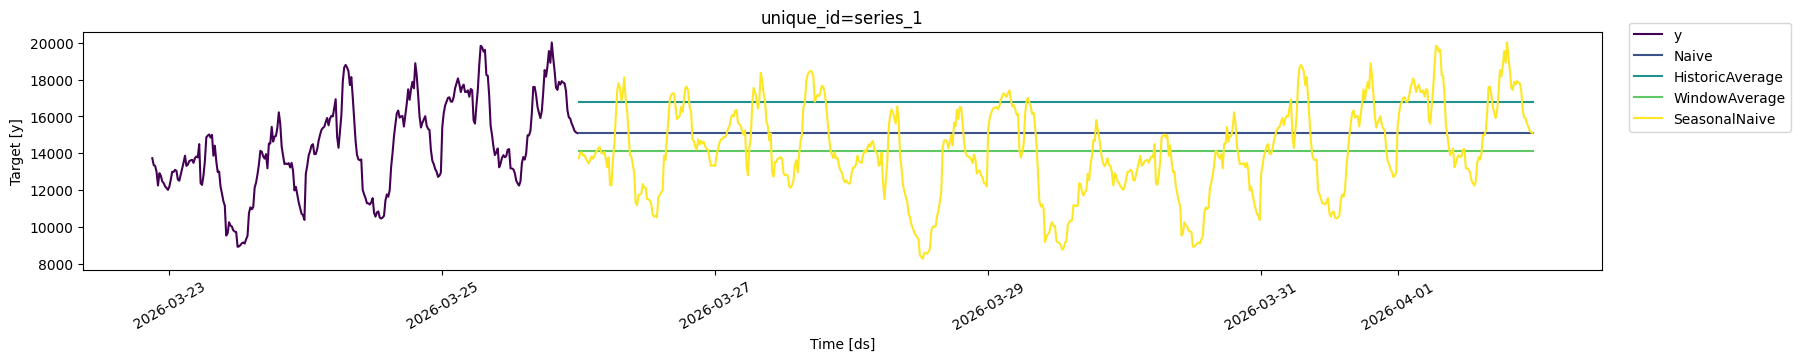

In [121]:
horizon = 96*7

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=96*7),
    SeasonalNaive(season_length=96*7)
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=filtered_data)
preds = sf.predict(h=horizon)

plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=300, 
    palette="viridis")

## Evaluating last 7 day by training on Total-7 days

In [140]:
test = filtered_data.tail(horizon)
train = filtered_data.drop(test.index).reset_index(drop=True)

sf.fit(df=train)
preds = sf.predict(h=horizon)
test_predictions_v1 = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

metrics = evaluate(
    test_predictions_v1,
    metrics=[mae],
)
metrics.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,series_1,mae,2568.544643,3239.313759,3610.26528,4965.720238


In [141]:
metrics = metrics.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
metrics

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,2568.544643,3239.313759,3610.26528,4965.720238


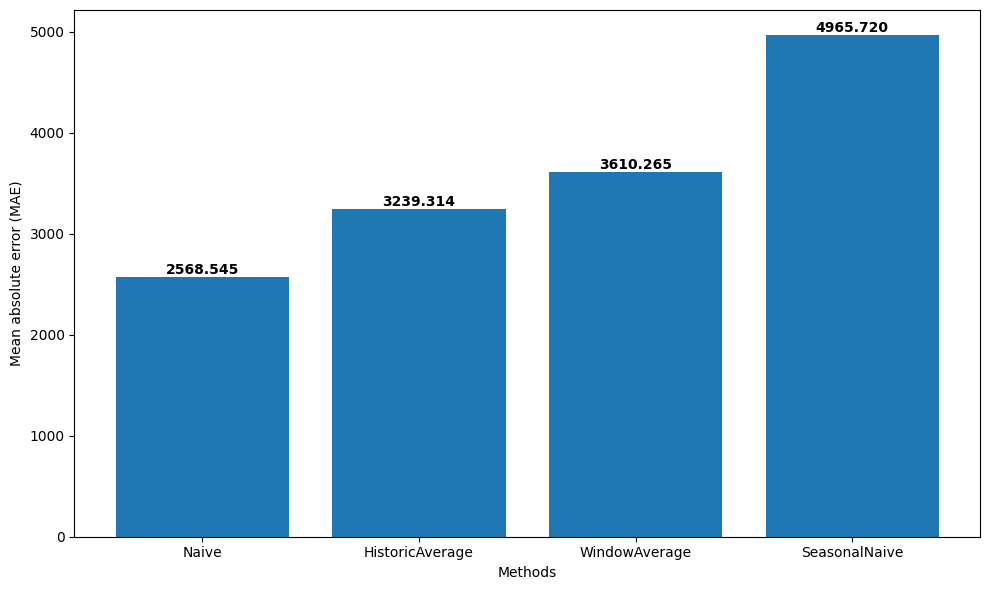

In [142]:
methods = metrics.columns[1:].tolist()  
values = metrics.iloc[0, 1:].tolist() 

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

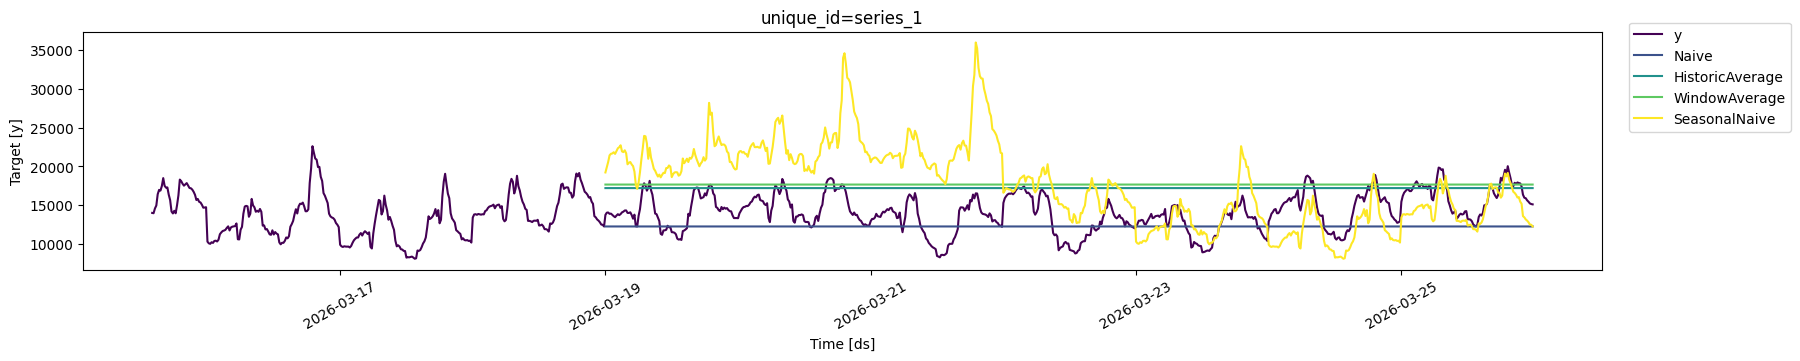

In [126]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=1000, 
    palette="viridis")

## Real business

In [144]:
horizon = 96*7

models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(2, 1, 1), alias="SARIMA (1,1,1,2,1,1,96)")
]

sf_arima = StatsForecast(models=models, freq="15min")
sf_arima.fit(df=train)
preds = sf_arima.predict(h=horizon)

test_predictions_v2 = pd.merge(test_predictions_v1, preds, 'inner', ['ds', 'unique_id'])

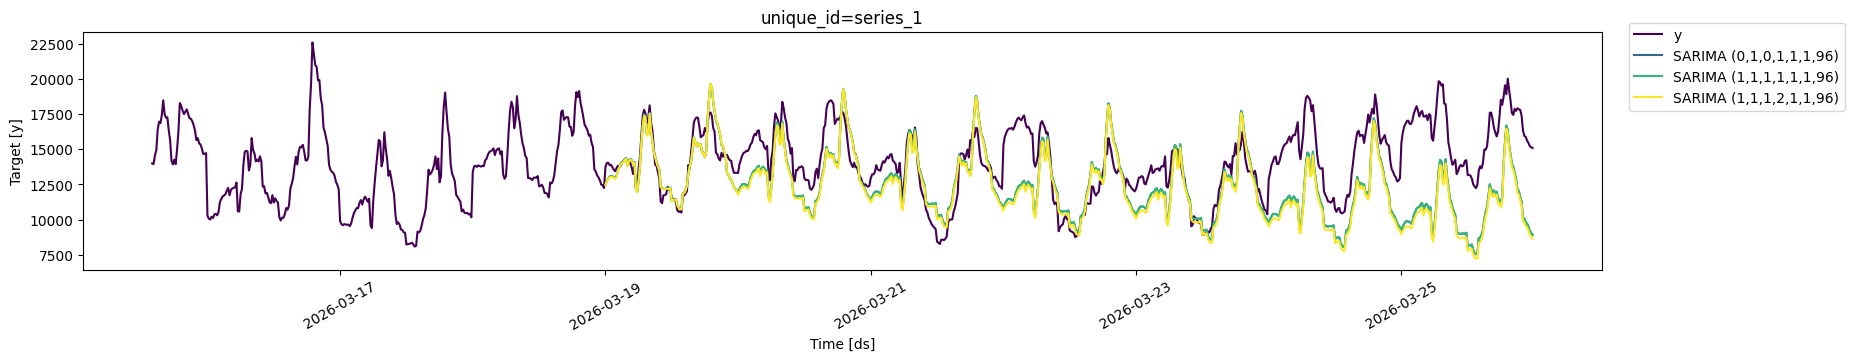

In [138]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=1000, 
    palette="viridis")

In [143]:
metrics = evaluate(
    predictions_merged,
    metrics=[mae],
)
metrics

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)","SARIMA (1,1,1,2,1,1,96)"
0,series_1,mae,2568.544643,3239.313759,3610.26528,4965.720238,2197.819691,2198.060015,2322.189263


### SARIMA with Exogeneous variables

In [155]:
data_with_exog = filtered_data.copy()
# data_with_exog["period_enum"] = data_with_exog["ds"].dt.hour * 4 + data_with_exog["ds"].dt.minute // 15 + 1
data_with_exog["weekday_enum"] = data_with_exog["ds"].dt.weekday + 1

test = data_with_exog.groupby("unique_id").tail(horizon)
train = data_with_exog.drop(test.index).reset_index(drop=True)

futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

,ds,unique_id,weekday_enum
4416,2026-03-19 00:00:00,series_1,4
4417,2026-03-19 00:15:00,series_1,4
4418,2026-03-19 00:30:00,series_1,4
4419,2026-03-19 00:45:00,series_1,4
4420,2026-03-19 01:00:00,series_1,4


In [156]:
train

,ds,y,unique_id,weekday_enum
0,2026-02-01 00:00:00,11446.6,series_1,7
1,2026-02-01 00:15:00,12066.8,series_1,7
2,2026-02-01 00:30:00,12510.9,series_1,7
3,2026-02-01 00:45:00,12502.6,series_1,7
4,2026-02-01 01:00:00,12423.8,series_1,7
...,...,...,...,...
4411,2026-03-18 22:45:00,12997.9,series_1,3
4412,2026-03-18 23:00:00,12787.9,series_1,3
4413,2026-03-18 23:15:00,12484.4,series_1,3
4414,2026-03-18 23:30:00,12462.6,series_1,3


In [157]:
models = [
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96) exog")
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=train)
exog_preds = sf.predict(h=horizon, X_df=futr_exog_df)

test_predictions_v3 = pd.merge(test_predictions_v2, exog_preds,  'inner', ['ds', 'unique_id'])

In [158]:
# arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
metrics = evaluate(
    test_predictions_v3,
    metrics=[mae],
)
metrics

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)","SARIMA (1,1,1,2,1,1,96)","SARIMA (1,1,1,1,1,1,96) exog"
0,series_1,mae,2568.544643,3239.313759,3610.26528,4965.720238,2197.819691,2198.060015,2322.189263,2179.358742


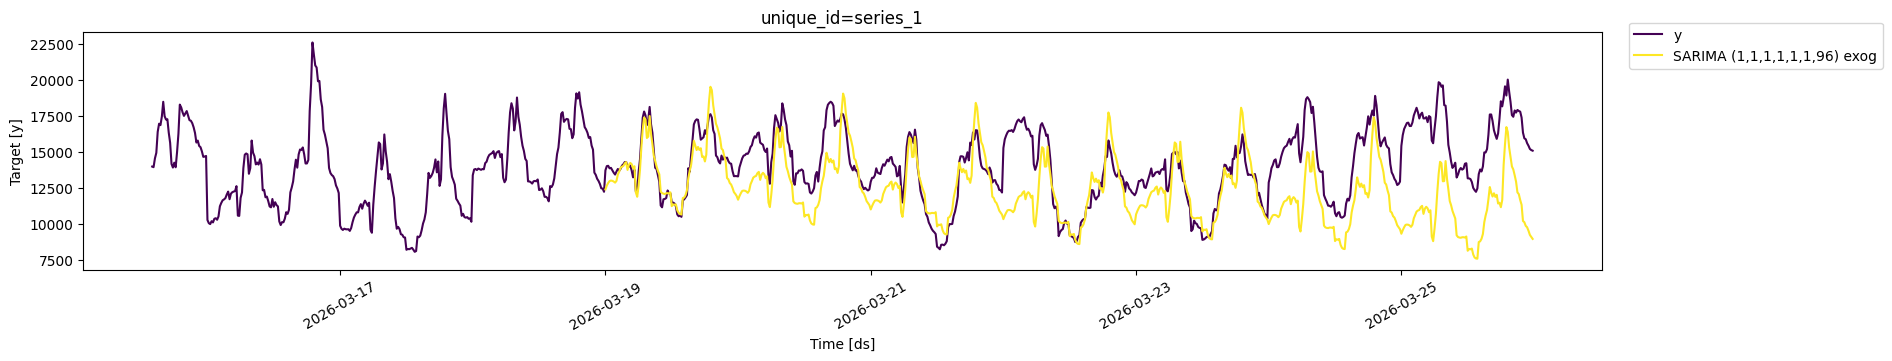

In [160]:
plot_series(
    df=filtered_data, 
    forecasts_df=exog_preds,  
    max_insample_length=1000, 
    palette="viridis")

### Last 7 days predictions comparison

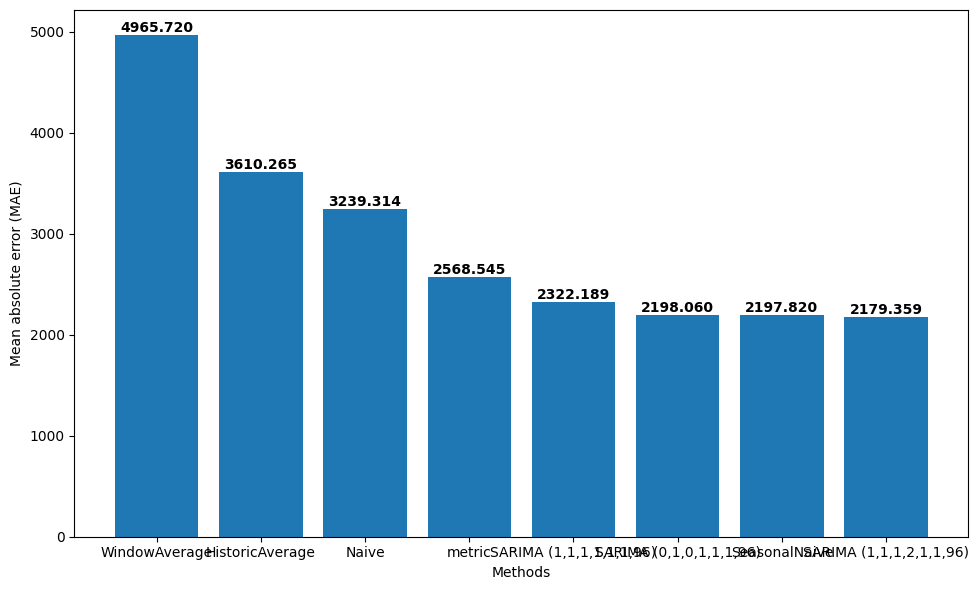

In [170]:
methods = metrics.columns[1:].tolist()  
values = metrics.iloc[0, 2:].tolist() 

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

### cross validation for naive forecast

In [230]:
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=96*7),
    SeasonalNaive(season_length=96*7),
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96)"),
    ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96)")
]

sf = StatsForecast(models=models, freq="15min")
cv_df = sf.cross_validation(
    h=horizon,
    df=filtered_data,
    n_windows=7,
    step_size=96,
    refit=True
)

cv_df.head()

,unique_id,ds,cutoff,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)"
0,series_1,2026-03-13 00:00:00,2026-03-12 23:45:00,21585.5,19664.8,17209.505859,19186.986458,16546.3,21791.238123,21815.959539
1,series_1,2026-03-13 00:15:00,2026-03-12 23:45:00,21921.1,19664.8,17209.505859,19186.986458,17325.3,22453.362884,22509.886460
2,series_1,2026-03-13 00:30:00,2026-03-12 23:45:00,21975.8,19664.8,17209.505859,19186.986458,18282.9,23339.507154,23426.365931
3,series_1,2026-03-13 00:45:00,2026-03-12 23:45:00,21775.5,19664.8,17209.505859,19186.986458,19322.5,24156.285542,24274.520204
4,series_1,2026-03-13 01:00:00,2026-03-12 23:45:00,21863.0,19664.8,17209.505859,19186.986458,19415.9,24279.164741,24425.983800


In [234]:
sf.fit(df=filtered_data)

# Now check the parameters
for i, model_obj in enumerate(sf.fitted_[0]):
    print(f"Model {i} ({models[i]}): {model_obj}")

Model 0 (Naive): Naive
Model 1 (HistoricAverage): HistoricAverage
Model 2 (WindowAverage): WindowAverage
Model 3 (SeasonalNaive): SeasonalNaive
Model 4 (SARIMA (0,1,0,1,1,1,96)): SARIMA (0,1,0,1,1,1,96)
Model 5 (SARIMA (1,1,1,1,1,1,96)): SARIMA (1,1,1,1,1,1,96)


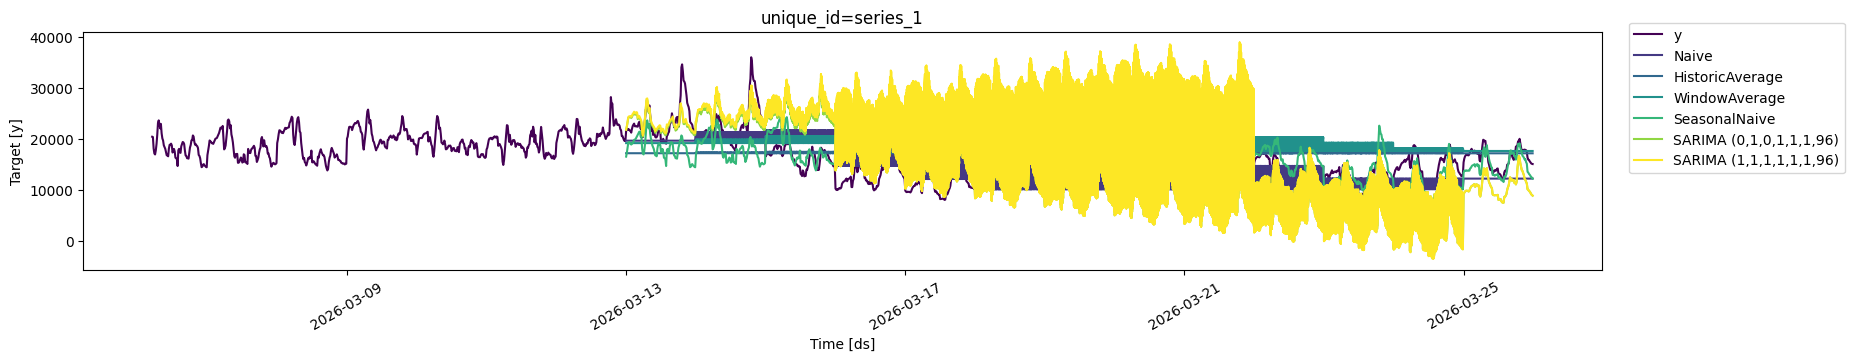

In [198]:
plot_series(
    df=filtered_data, 
    forecasts_df=cv_df.drop(["y", "cutoff"], axis=1), 
    max_insample_length=1900, 
    palette="viridis")

In [199]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval = cv_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)"
0,mae,4299.411416,3719.589362,5282.137672,5810.053975,8129.344706,8661.095768


### Cross Validation for SARIMA with exogenous variable

In [202]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (0,1,0,1,1,1,96) exog"),
    # ARIMA(order=(1,1,1), season_length=96, seasonal_order=(1, 1, 1), alias="SARIMA (1,1,1,1,1,1,96) exog")
]

sf = StatsForecast(models=models, freq="15min")
cv_df_exog = sf.cross_validation(
    h=horizon,
    df=data_with_exog,
    n_windows=7,
    step_size=96,
    refit=True
)
cv_df_exog.head()

,unique_id,ds,cutoff,y,"SARIMA (0,1,0,1,1,1,96) exog"
0,series_1,2026-03-13 00:00:00,2026-03-12 23:45:00,21585.5,21605.781000
1,series_1,2026-03-13 00:15:00,2026-03-12 23:45:00,21921.1,22268.450619
2,series_1,2026-03-13 00:30:00,2026-03-12 23:45:00,21975.8,23153.964923
3,series_1,2026-03-13 00:45:00,2026-03-12 23:45:00,21775.5,23970.406003
4,series_1,2026-03-13 01:00:00,2026-03-12 23:45:00,21863.0,24093.200514


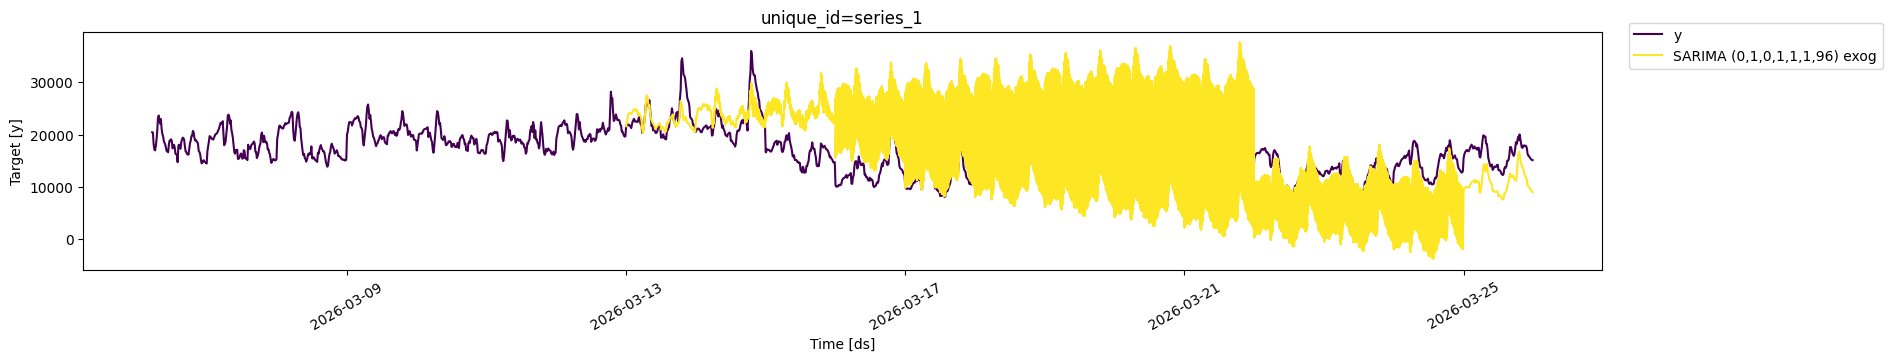

In [203]:
plot_series(
    df=data_with_exog, 
    forecasts_df=cv_df_exog.drop(["y", "cutoff"], axis=1), 
    max_insample_length=1900, 
    palette="viridis")

In [205]:
cv_eval_exog = evaluate(
    cv_df_exog.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval_exog = cv_eval_exog.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval_exog

,metric,"SARIMA (0,1,0,1,1,1,96) exog"
0,mae,8575.205087


In [220]:
filtered_data.drop(columns={"time_slot", "rolling_avg_20d"}, inplace=True)

In [223]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96)"),
]

sf = StatsForecast(models=models, freq="15min")
cv_df_new = sf.cross_validation(
    h=horizon,
    df=filtered_data,
    n_windows=7,
    step_size=96,
    refit=True
)

cv_df_v3 = pd.merge(cv_df_v3, cv_df_new, 'inner', ['ds', 'cutoff', 'unique_id', 'y'])
cv_df_v3.head()

,unique_id,ds,cutoff,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)","SARIMA (0,1,0,0,1,3,96)","SARIMA (0,1,0,0,1,1,96)"
0,series_1,2026-03-13 00:00:00,2026-03-12 23:45:00,21585.5,19664.8,17209.505859,19186.986458,16546.3,21791.238123,21815.959539,21905.732640,21697.417914
1,series_1,2026-03-13 00:15:00,2026-03-12 23:45:00,21921.1,19664.8,17209.505859,19186.986458,17325.3,22453.362884,22509.886460,22561.594304,22346.233875
2,series_1,2026-03-13 00:30:00,2026-03-12 23:45:00,21975.8,19664.8,17209.505859,19186.986458,18282.9,23339.507154,23426.365931,23431.428114,23238.187046
3,series_1,2026-03-13 00:45:00,2026-03-12 23:45:00,21775.5,19664.8,17209.505859,19186.986458,19322.5,24156.285542,24274.520204,24228.730297,24061.186683
4,series_1,2026-03-13 01:00:00,2026-03-12 23:45:00,21863.0,19664.8,17209.505859,19186.986458,19415.9,24279.164741,24425.983800,24356.049180,24191.606998


In [224]:
cv_eval_v3 = evaluate(
    cv_df_v3.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval_v3 = cv_eval_v3.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval_v3

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive,"SARIMA (0,1,0,1,1,1,96)","SARIMA (1,1,1,1,1,1,96)","SARIMA (0,1,0,0,1,3,96)","SARIMA (0,1,0,0,1,1,96)"
0,mae,4299.411416,3719.589362,5282.137672,5810.053975,8129.344706,8661.095768,7809.31436,8670.358516


### Simple Rolling Average

In [213]:
import pandas as pd

# 1. Define the parameters for the windows
# We want to start by predicting the week starting March 13th
# The last data point the model "knows" (cutoff) would be March 12th 23:45
start_cutoff = pd.to_datetime('2026-03-12 23:45:00')
n_windows = 7  # To predict 13th-19th, 14th-20th, etc.
horizon = 96 * 7  # 7 days

cv_rolling_list = []

# 2. Loop to create each cross-validation window
for i in range(n_windows):
    # Current cutoff for this window
    current_cutoff = start_cutoff + pd.Timedelta(days=i)
    
    # Define the 7-day prediction range for this cutoff
    forecast_start = current_cutoff + pd.Timedelta(minutes=15)
    forecast_end = current_cutoff + pd.Timedelta(days=7)
    
    # Filter the rolling average data for this specific forecast range
    window_preds = filtered_data[
        (filtered_data['ds'] >= forecast_start) & 
        (filtered_data['ds'] <= forecast_end)
    ].copy()
    
    # Add the cutoff column to match cv_df structure
    window_preds['cutoff'] = current_cutoff
    
    cv_rolling_list.append(window_preds)

# 3. Combine into a single dataframe
cv_rolling_df = pd.concat(cv_rolling_list).reset_index(drop=True)

# 4. Clean up columns to match your cv_df exactly
cv_rolling_df = cv_rolling_df[['unique_id', 'ds', 'cutoff', 'y', 'rolling_avg_20d']]

# Display the first few rows and the different cutoffs created
print(f"Generated windows for cutoffs: {cv_rolling_df['cutoff'].unique()}")
cv_rolling_df.head()

Generated windows for cutoffs: <DatetimeArray>
['2026-03-12 23:45:00', '2026-03-13 23:45:00', '2026-03-14 23:45:00',
 '2026-03-15 23:45:00', '2026-03-16 23:45:00', '2026-03-17 23:45:00',
 '2026-03-18 23:45:00']
Length: 7, dtype: datetime64[ns]


,unique_id,ds,cutoff,y,rolling_avg_20d
0,series_1,2026-03-13 00:00:00,2026-03-12 23:45:00,21585.5,16564.265
1,series_1,2026-03-13 00:15:00,2026-03-12 23:45:00,21921.1,17433.995
2,series_1,2026-03-13 00:30:00,2026-03-12 23:45:00,21975.8,18423.400
3,series_1,2026-03-13 00:45:00,2026-03-12 23:45:00,21775.5,18968.225
4,series_1,2026-03-13 01:00:00,2026-03-12 23:45:00,21863.0,18996.380


In [214]:
evaluate(
    cv_rolling_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)

,unique_id,metric,rolling_avg_20d
0,series_1,mae,3927.652049
